# Transformer Architecture in Particle Physics from scratch
### A step-by-step build of a tiny GPT-style model (TinyGPT)

This notebook walks through the core ideas behind transformer architectures — tokenization, embeddings, attention blocks, training, and generation — using a small toy dataset.

Import libraries

In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

import torch
import torch.nn as nn
import torch.nn.functional as F
import random

from google.colab import files
uploaded = files.upload()

2.11.0+cpu
False


Saving transformer_blocks.py to transformer_blocks.py


In [ ]:
from transformer_blocks import Block

Data

In [ ]:
# We are considering a small dataset just to understand the concept
corpus = [
    "hello friends how are you",
    "the tea is very hot",
    "my name is Shahzaib Abbas",
    "the roads of Karachi are busy",
    "it is raining in Karachi",
    "the train is late again",
    "i love eating samosas and drinking tea",
    "Eid is my favorite festival",
    "Eid brings lights and sweets",
    "Argentina won the football match"
]

Preprocessing the data: We have to prepare data in the form in whcih LLM can understand data. LLM do not understand human language

In [ ]:
corpus = [s + " <END>" for s in corpus] # Add END after every sentence
text = " ".join(corpus)   # text is variable here. Join all the sentences
print (text)

hello friends how are you <END> the tea is very hot <END> my name is Shahzaib Abbas <END> the roads of Karachi are busy <END> it is raining in Karachi <END> the train is late again <END> i love eating samosas and drinking tea <END> Eid is my favorite festival <END> Eid brings lights and sweets <END> Argentina won the football match <END>



Splitting the text on the basis of wide spaces (). The tea is very hot

In [ ]:
words = list(set(text.split()))
print(words)

['<END>', 'hot', 'brings', 'football', 'Abbas', 'Argentina', 'very', 'love', 'drinking', 'late', 'hello', 'train', 'my', 'it', 'eating', 'roads', 'of', 'won', 'Shahzaib', 'and', 'friends', 'how', 'are', 'lights', 'name', 'Eid', 'is', 'busy', 'samosas', 'you', 'again', 'match', 'festival', 'the', 'in', 'Karachi', 'i', 'raining', 'favorite', 'sweets', 'tea']


Output: you can see the words are separated and become tokens. Tokens can be words, characters, etc

Now checking the vocabulary of model. Vocab: how many unique words you have given in your data

In [ ]:
vocab_size = len(words)
print(vocab_size)

41


Still the model is unable to understand words, so converting words into numbers by establishing a dictionary:

In [ ]:
word2idx = {w: i for i, w in enumerate(words)} # w:i means converting each word into numbers
print("word2idx : ", word2idx) # Output: number assigned to each word

word2idx :  {'<END>': 0, 'hot': 1, 'brings': 2, 'football': 3, 'Abbas': 4, 'Argentina': 5, 'very': 6, 'love': 7, 'drinking': 8, 'late': 9, 'hello': 10, 'train': 11, 'my': 12, 'it': 13, 'eating': 14, 'roads': 15, 'of': 16, 'won': 17, 'Shahzaib': 18, 'and': 19, 'friends': 20, 'how': 21, 'are': 22, 'lights': 23, 'name': 24, 'Eid': 25, 'is': 26, 'busy': 27, 'samosas': 28, 'you': 29, 'again': 30, 'match': 31, 'festival': 32, 'the': 33, 'in': 34, 'Karachi': 35, 'i': 36, 'raining': 37, 'favorite': 38, 'sweets': 39, 'tea': 40}


In [ ]:
idx2word = {i: w for w, i in word2idx.items()}
print("idx2word : ", idx2word)

idx2word :  {0: '<END>', 1: 'hot', 2: 'brings', 3: 'football', 4: 'Abbas', 5: 'Argentina', 6: 'very', 7: 'love', 8: 'drinking', 9: 'late', 10: 'hello', 11: 'train', 12: 'my', 13: 'it', 14: 'eating', 15: 'roads', 16: 'of', 17: 'won', 18: 'Shahzaib', 19: 'and', 20: 'friends', 21: 'how', 22: 'are', 23: 'lights', 24: 'name', 25: 'Eid', 26: 'is', 27: 'busy', 28: 'samosas', 29: 'you', 30: 'again', 31: 'match', 32: 'festival', 33: 'the', 34: 'in', 35: 'Karachi', 36: 'i', 37: 'raining', 38: 'favorite', 39: 'sweets', 40: 'tea'}


In [ ]:
data = torch.tensor([word2idx[w] for w in text.split()], dtype=torch.long)
print("data : ", data) # finally we got a 1-D tensor in which numbers are arranged and each number corresponds to words of data
print(len(data)) # 62 is the length of data

data :  tensor([10, 20, 21, 22, 29,  0, 33, 40, 26,  6,  1,  0, 12, 24, 26, 18,  4,  0,
        33, 15, 16, 35, 22, 27,  0, 13, 26, 37, 34, 35,  0, 33, 11, 26,  9, 30,
         0, 36,  7, 14, 28, 19,  8, 40,  0, 25, 26, 12, 38, 32,  0, 25,  2, 23,
        19, 39,  0,  5, 17, 33,  3, 31,  0])
63


In [ ]:
block_size = 6 #when data is numerous , it is sent as input as chunks
#if i define cat sat on a mat but intitialzied block size 2 then it will only look at the last 2 words
#sequences 16 means how many sequences it will make
#block size means 2 kay ilawa how many words it will see in future
embedding_dim = 32
n_heads = 2 #no of parameters, related to particle physics
n_layers = 2
lr = 1e-3 #equivalent to step size
epochs = 1500 #no of times data is Passed through the models/iterations

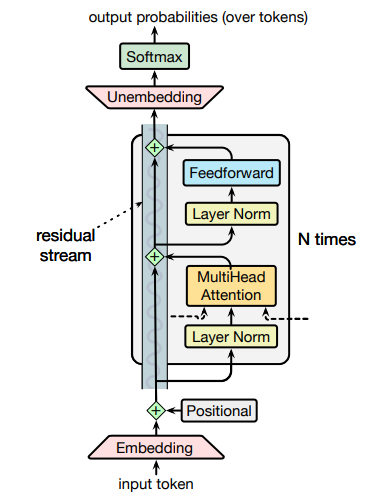

In [ ]:
def get_batch(batch_size=16):# 16 sequences at a time , this is the batch size
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])#input eg=[token 12, token 13, token 14]
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])#output eg y =[token 13, token 14, token 15] ->token 15 is the word predicted by the model
    return x, y

In [ ]:
class TinyGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)

        self.position_embedding = nn.Embedding(block_size, embedding_dim)
        self.blocks = nn.Sequential(*[Block(embedding_dim, block_size, n_heads) for _ in range(n_layers)])

        self.ln_f = nn.LayerNorm(embedding_dim)
        self.head = nn.Linear(embedding_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)

        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, 1)
            idx = torch.cat((idx, next_idx), dim=1)
        return idx



model = TinyGPT()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for step in range(epochs):
    xb, yb = get_batch()
    logits, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 300 == 0:
        print(f"Step {step}, loss={loss.item():.4f}")



context = torch.tensor([[word2idx["hello"]]], dtype=torch.long)
out = model.generate(context, max_new_tokens=15)

print("\nGenerated text:\n")
print(" ".join(idx2word[int(i)] for i in out[0]))

Step 0, loss=3.9073
Step 300, loss=0.1599
Step 600, loss=0.1207
Step 900, loss=0.1310
Step 1200, loss=0.1692

Generated text:

hello again <END> i love eating samosas and drinking tea <END> Eid is my favorite festival
